In [1]:
import pandas as pd
import numpy as np
from cca_classes import LogNormalJumpCCAPricer, BaselineCCAPricer, compute_lcl_usd, compute_barrier_kvm
from multiprocessing.pool import ThreadPool
from multiprocessing import cpu_count

## Baseline Model Panel

In [2]:

study_sovereigns = [
    'Saudi Arabia', 'UAE (Abu Dhabi)', 'Qatar', 'Colombia',
    'Mexico', 'Brazil', 'Egypt', 'Malaysia','Indonesia', 'Philippines', 'Turkey', 'Chile', 'China',
    'South Africa', 'South Korea', 'Thailand']


cca_panel_df = pd.read_csv('../data/processed/CCA_V2/CCA_panel.csv')
cca_panel_df['date'] = pd.to_datetime(cca_panel_df['date'])
cca_panel_df = cca_panel_df[cca_panel_df['country'].isin(study_sovereigns)].copy()

T = 5.0
vol_window = 52
freq = 'W'
ann_factor = np.sqrt(52)


cca_panel_df.set_index(['date','country'], inplace=True)
cca_panel_df = (
    cca_panel_df
    .groupby('country')
    .resample(freq, level='date')
    .last()
)
cca_panel_df.reset_index(inplace=True)


## M2 Specific Data

In [3]:
ovx_df = pd.read_csv('../data/processed/Macroeconomic_variables/OVXCLS.csv')
ovx_df['date'] = pd.to_datetime(ovx_df['date'])
ovx_df = ovx_df.sort_values('date')
ovx_df['OVXCLS'] = ovx_df['OVXCLS'].ffill()

cca_panel_df = cca_panel_df.reset_index()
cca_panel_df = cca_panel_df.sort_values('date')

cca_panel_df = pd.merge_asof(
    cca_panel_df,
    ovx_df[['date', 'OVXCLS']],
    on='date',
    direction='backward'
)

cca_panel_df.set_index(['date', 'country'], inplace=True)
cca_panel_df = (
    cca_panel_df
    .groupby('country')
    .resample(freq, level='date')
    .last()
)
cca_panel_df.reset_index(inplace=True)
print(f"OVX NAs: {cca_panel_df['OVXCLS'].isna().sum()}")

OVX NAs: 0


## M2 Parameters & Pricer

In [4]:
gamma = 0.15

mu_J           = -0.016617
sigma_J        =  0.099499
logit_const    = -2.782760
logit_ovx_coef =  0.054707

pricer = LogNormalJumpCCAPricer(mu_J=mu_J*gamma , sigma_J=sigma_J*gamma, max_terms=150)
baseline_pricer = BaselineCCAPricer()

pricer._cache = {}

# no standardization needed

def ovx_to_lambda(ovx):
    if np.isnan(ovx) or ovx <= 0:
        return 0.0
    logit_p   = logit_const + logit_ovx_coef * ovx
    p_hat     = 1 / (1 + np.exp(-logit_p))
    p_clipped = np.clip(p_hat, 1e-8, 1 - 1/np.e)
    return min(-np.log(1 - p_clipped) * 52, 52.0)

In [5]:
def prepare_country(df):
    df = df.copy().sort_values('date').reset_index(drop=True)

    df['LCL_usd'] = [
        compute_lcl_usd(m, bd, fx, rd, rf, T)
        for m, bd, fx, rd, rf in zip(
            df['monetary_base_bn_local'],
            df['domestic_debt_bn_local'],
            df['fx_rate'],
            df['domestic_rate'],
            df['risk_free_rate']
        )
    ]

    log_ret         = np.log(df['LCL_usd'] / df['LCL_usd'].shift(1))
    df['sigma_lcl'] = log_ret.rolling(window=vol_window).std() * ann_factor

    df['B_f'] = [
        compute_barrier_kvm(debt, rf, T)
        for debt, rf in zip(df['external_debt_bn_usd'], df['risk_free_rate'])
    ]

    df['lambda_annual'] = df['OVXCLS'].apply(ovx_to_lambda)

    return df

## Run M2

In [6]:
results = []
print("Starting M2 calibration...")

for country, group in cca_panel_df.groupby('country'):
    print(f"Processing {country}...")
    df = prepare_country(group)

    implied_V       = []
    implied_sigma_diff = []
    implied_sigma_V = []
    cca_converged   = []

    prev = None

    for i, row in df.iterrows():
        lam = row['lambda_annual']

        cca = pricer.solve_CCA_M2(
            row['LCL_usd'], row['sigma_lcl'], row['B_f'],
            row['risk_free_rate'], T, lam,
            prev_solution=prev
        )

        prev = cca if cca['converged'] else prev

        implied_V.append(cca['implied_V'])
        implied_sigma_diff.append(cca['implied_sigma_diff'])
        implied_sigma_V.append(cca['implied_sigma_V'])
        cca_converged.append(cca['converged'])

    df['implied_V']          = implied_V
    df['implied_sigma_diff'] = implied_sigma_diff
    df['implied_sigma_V']    = implied_sigma_V
    df['cca_converged']      = cca_converged

    results.append(df)

results = pd.concat(results, ignore_index=True)

START_DATE = '2015-01-01'
END_DATE   = '2024-12-31'
results    = results[
    (results['date'] >= START_DATE) & (results['date'] <= END_DATE)
].copy()

print(f"Calibration complete!")
print(f"Converged: {results['cca_converged'].sum()} / {len(results)}")
print(f"Convergence rate: {results['cca_converged'].mean()*100:.1f}%")

Starting M2 calibration...
Processing Brazil...
Processing Chile...
Processing China...
Processing Colombia...
Processing Egypt...
Processing Indonesia...
Processing Malaysia...
Processing Mexico...
Processing Philippines...
Processing Qatar...
Processing Saudi Arabia...
Processing South Africa...
Processing South Korea...
Processing Thailand...
Processing Turkey...
Processing UAE (Abu Dhabi)...
Calibration complete!
Converged: 8352 / 8352
Convergence rate: 100.0%


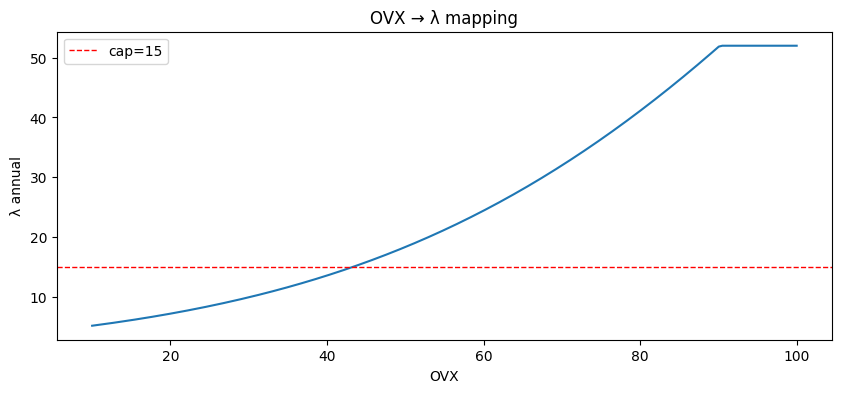

λ at OVX=20: 7.19
λ at OVX=35: 11.62
λ at OVX=55: 21.20
λ at OVX=80: 41.11


In [18]:
import matplotlib.pyplot as plt

ovx_range = np.linspace(10, 100, 200)
lambdas   = [ovx_to_lambda(o) for o in ovx_range]

plt.figure(figsize=(10, 4))
plt.plot(ovx_range, lambdas)
plt.axhline(15, color='red', ls='--', lw=1, label='cap=15')
plt.xlabel('OVX')
plt.ylabel('λ annual')
plt.title('OVX → λ mapping')
plt.legend()
plt.show()

print(f"λ at OVX=20: {ovx_to_lambda(20):.2f}")
print(f"λ at OVX=35: {ovx_to_lambda(35):.2f}")
print(f"λ at OVX=55: {ovx_to_lambda(55):.2f}")
print(f"λ at OVX=80: {ovx_to_lambda(80):.2f}")

In [7]:
results[[
    'date', 'country', 'cds_spread', 'risk_free_rate',
    'implied_V', 'implied_sigma_V', 'cca_converged',
    'B_f', 'LCL_usd', 'sigma_lcl', 'lambda_annual'
]].to_csv('../output/results/final_inchallah/M2_results_5YCDS_weekly_15_dampening.csv', index=False)

In [13]:
# use the actual South Korea failing values
V_sol     = 475.0
B_f       = 436.07
r_f       = 0.05
lam       = 12.68
LCL_usd   = 81.27
sigma_lcl = 0.1679
sig_tiny  = 1e-6

call,   delta = pricer._series(V_sol, B_f, r_f, T, sig_tiny, lam)
call_J, _     = pricer._series(V_sol*(1+pricer.k), B_f, r_f, T, sig_tiny, lam)

jump_contribution = np.sqrt(lam) * abs(call_J - call)
diff_contribution = sig_tiny * V_sol * delta
target            = LCL_usd * sigma_lcl

print(f"Jump contribution at σ_diff→0: {jump_contribution:.4f}")
print(f"Diff contribution at σ_diff→0: {diff_contribution:.4f}")
print(f"Total eq2 LHS:                 {np.sqrt(jump_contribution**2 + diff_contribution**2):.4f}")
print(f"Target LCL·σ_lcl:              {target:.4f}")
print(f"Feasible: {jump_contribution <= target}")

Jump contribution at σ_diff→0: 18.8005
Diff contribution at σ_diff→0: 0.0005
Total eq2 LHS:                 18.8005
Target LCL·σ_lcl:              13.6452
Feasible: False
